In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from tqdm.autonotebook import tqdm
# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 8,                    # Base font size
    "axes.labelsize": 8,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})



/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_18918/1003344669.py:9: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


In [2]:
STN_DATA_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
STN_DATA_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
STN_DATA_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
DEL_LIM_ARR = [0.1, 0.2, 0.5, 1.0] 
FILE_PATHS = [STN_DATA_path_PD, STN_DATA_path_std_DBS, STN_DATA_path_sector_DBS]
TYPE = ['PD', 'STD_DBS', 'SECTOR_DBS']
LAT_STRENGTH = 0.0425


In [3]:
yaml_path = os.path.join(project_root, 'params', 'decision_making_task_params', 'non_stationary_bandits', 'params.yaml')
params = load_yaml(yaml_path)


In [4]:

TRIALS = params['TRIALS']
EPOCHS = params['EPOCHS']
BINS = params['NUM_BINS']
LR = params['LR'] 
NUM_ARMS =params['NUM_ARMS']
SCALING_FACTOR = params['SCALING_FACTOR']   
TIME_STAMP_CHANGE = params['TIME_STAMP_CHANGE']
BIN_SIZE = TRIALS//BINS
BIN_CHANGE = TIME_STAMP_CHANGE // BIN_SIZE

In [5]:
# ------------------------------------------------------------
# Choice-variability and DP/Q-value error metrics only
# ------------------------------------------------------------
# Choice variability = alpha * normalized entropy + (1-alpha) * switching.
# Q-error compares dp_monitor values with the TRUE NORMALIZED reward means.


def _as_torch(x, dtype=None):
    """Convert numpy/list/torch input to a CPU torch tensor."""
    if isinstance(x, torch.Tensor):
        out = x.detach().cpu()
    elif isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], torch.Tensor):
        out = torch.stack([xx.detach().cpu() for xx in x])
    elif isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], np.ndarray):
        out = torch.as_tensor(np.stack(x))
    else:
        out = torch.as_tensor(x)
    if dtype is not None:
        out = out.to(dtype)
    return out


def _sort_keys_like_arms(keys):
    """Sort arm keys robustly when keys may be int, np.int64, or strings."""
    try:
        return sorted(keys, key=lambda k: int(k))
    except Exception:
        return sorted(keys)


def _get_arm_key(dp_monitor, arm_idx, sorted_keys):
    if arm_idx in dp_monitor:
        return arm_idx
    for k in sorted_keys:
        try:
            if int(k) == int(arm_idx):
                return k
        except Exception:
            pass
    return sorted_keys[arm_idx]


def _ensure_reward_means_are_normalized(reward_vec, scaling_factor):
    """
    Return reward means on the same normalized scale used during training.
    If values look like raw NSB rewards, divide by SCALING_FACTOR.
    """
    reward_vec = _as_torch(reward_vec, torch.float32).flatten()

    if scaling_factor is None or float(scaling_factor) == 1.0:
        return reward_vec

    finite_vals = reward_vec[torch.isfinite(reward_vec)]
    if finite_vals.numel() == 0:
        return reward_vec

    if torch.max(torch.abs(finite_vals)).item() > 10:
        reward_vec = reward_vec / float(scaling_factor)

    return reward_vec


def make_true_reward_mean_matrix(env, trials, num_arms, time_stamp_change, scaling_factor):
    """
    Build true reward means by trial on the normalized reward scale.
    Output shape: (trials, num_arms).
    """
    fallback_before_raw = np.array([20, 40, 25], dtype=float)
    fallback_after_raw = np.array([25, 30, 50], dtype=float)

    before = getattr(env, "mean_reward", fallback_before_raw)
    after = getattr(env, "mean_rew_change", fallback_after_raw)

    before = _ensure_reward_means_are_normalized(before, scaling_factor)
    after = _ensure_reward_means_are_normalized(after, scaling_factor)

    if before.numel() != num_arms:
        before = _ensure_reward_means_are_normalized(fallback_before_raw, scaling_factor)
    if after.numel() != num_arms:
        after = _ensure_reward_means_are_normalized(fallback_after_raw, scaling_factor)

    true_means = torch.zeros((trials, num_arms), dtype=torch.float32)
    true_means[:time_stamp_change] = before
    true_means[time_stamp_change:] = after
    return true_means


def compute_choice_variability_metrics(actions, n_arms=None, window_size=15, alpha=0.7):
    """
    Compute choice variability from action sequences.

    normalized entropy: how broadly arms are sampled within each window.
    switching: fraction of trial-to-trial action changes within each window.
    entropy + switching = alpha * entropy + (1-alpha) * switching.
    """
    actions = _as_torch(actions, torch.long)

    if actions.ndim != 2:
        raise ValueError(f"actions should have shape (epochs, trials), got {tuple(actions.shape)}")

    n_epochs, n_trials = actions.shape
    if n_arms is None:
        n_arms = int(actions.max().item()) + 1

    out_len = n_trials - window_size + 1
    if out_len <= 0:
        raise ValueError("window_size must be <= number of trials")

    entropy_all = torch.zeros((n_epochs, out_len), dtype=torch.float32)
    switching_all = torch.zeros((n_epochs, out_len), dtype=torch.float32)
    max_entropy = np.log(n_arms) if n_arms > 1 else 1.0

    for e in range(n_epochs):
        epoch_actions = actions[e]
        for start in range(out_len):
            w = epoch_actions[start:start + window_size]
            counts = torch.bincount(w, minlength=n_arms).float()
            probs = counts / counts.sum()
            probs = probs[probs > 0]
            entropy_all[e, start] = -(probs * torch.log(probs)).sum() / max_entropy
            switching_all[e, start] = (w[1:] != w[:-1]).float().mean()

    combined = alpha * entropy_all + (1 - alpha) * switching_all

    return {
        "window_size": window_size,
        "alpha_entropy": alpha,
        "mean_entropy": entropy_all.mean().item(),
        "mean_switching": switching_all.mean().item(),
        "mean_combined_variability": combined.mean().item(),
        "entropy": entropy_all,
        "switching": switching_all,
        "combined_variability": combined,
    }


def _standardize_single_arm_dp_array(arr, n_trials, arm_key=None):
    """Convert dp_monitor[arm] to shape (epochs, trials)."""
    arr = _as_torch(arr, torch.float32)
    while arr.ndim > 2 and arr.shape[-1] == 1:
        arr = arr.squeeze(-1)

    if arr.ndim == 1:
        if arr.shape[0] == n_trials:
            arr = arr.unsqueeze(0)
        else:
            raise ValueError(f"Arm {arm_key}: cannot infer DP shape {tuple(arr.shape)}")

    if arr.ndim != 2:
        raise ValueError(f"Arm {arm_key}: expected DP shape (epochs,trials), got {tuple(arr.shape)}")

    if arr.shape[1] == n_trials:
        return arr
    if arr.shape[0] == n_trials:
        return arr.T

    raise ValueError(f"Arm {arm_key}: expected one dimension to equal trials={n_trials}, got {tuple(arr.shape)}")


def dp_monitor_to_q_array(dp_monitor, n_trials, n_arms):
    """
    Convert per-arm dp_monitor into Q array with shape (epochs, trials, arms).
    Expected format: dp_monitor[arm].shape = (epochs, trials, 1).
    """
    if not isinstance(dp_monitor, dict):
        raise ValueError("Expected dp_monitor as dict: {arm: tensor(epochs,trials,1)}")

    sorted_keys = _sort_keys_like_arms(list(dp_monitor.keys()))
    if len(sorted_keys) < n_arms:
        raise ValueError(f"dp_monitor has {len(sorted_keys)} arms but n_arms={n_arms}")

    per_arm_values = []
    for arm_idx in range(n_arms):
        key = _get_arm_key(dp_monitor, arm_idx, sorted_keys)
        per_arm_values.append(_standardize_single_arm_dp_array(dp_monitor[key], n_trials, arm_key=key))

    n_common_epochs = min(arr.shape[0] for arr in per_arm_values)
    per_arm_values = [arr[:n_common_epochs] for arr in per_arm_values]
    return torch.stack(per_arm_values, dim=2)


def compute_q_error_metrics(dp_monitor, true_means):
    """
    Compute DP/Q-value RMSE using all arm values.
    Q-error = Q_i(t) - true_mean_i(t), averaged as RMSE across arms/trials/epochs.
    """
    true_means = _as_torch(true_means, torch.float32)
    n_trials, n_arms = true_means.shape
    q_values = dp_monitor_to_q_array(dp_monitor, n_trials=n_trials, n_arms=n_arms)

    if q_values.shape[1:] != true_means.shape:
        raise ValueError(f"q_values has shape {tuple(q_values.shape)}, true_means has shape {tuple(true_means.shape)}")

    q_error = q_values - true_means.unsqueeze(0)
    q_rmse_by_epoch_trial = torch.sqrt(torch.mean(q_error ** 2, dim=2))

    return {
        "mean_q_rmse": q_rmse_by_epoch_trial.mean().item(),
        "q_rmse_by_epoch_trial": q_rmse_by_epoch_trial,
        "q_error": q_error,
    }


def nested_defaultdict_to_dict(d):
    """Convert defaultdict(dict) into a normal nested dict before saving."""
    return {outer_key: dict(inner_dict) for outer_key, inner_dict in d.items()}


In [6]:
env = NonStationaryEnv(
    num_arms = NUM_ARMS, 
    mean_reward = np.array([20, 40, 25])/SCALING_FACTOR, #np.array([5,40,10])/SCALING_FACTOR, (20,40,10)
    std = np.array([2,2,2])/SCALING_FACTOR, 
    mean_rew_change = np.array([25, 35, 50])/SCALING_FACTOR, #np.array([10,20,60])/SCALING_FACTOR, (10,20,60)
    std_change = np.array([2,2,2])/SCALING_FACTOR, 
    time_stamp_change = TIME_STAMP_CHANGE)

BEST_ARM_BEFORE = 1
BEST_ARM_AFTER = 2

BEST_ARM = torch.zeros((EPOCHS,TRIALS), dtype=int)
BEST_ARM[:,:TIME_STAMP_CHANGE] = BEST_ARM_BEFORE
BEST_ARM[:,TIME_STAMP_CHANGE:] = BEST_ARM_AFTER  

TRUE_MEAN_REWARDS = make_true_reward_mean_matrix(
    env=env,
    trials=TRIALS,
    num_arms=NUM_ARMS,
    time_stamp_change=TIME_STAMP_CHANGE,
    scaling_factor=SCALING_FACTOR
)



In [7]:
ARM_MONITOR = defaultdict(dict)
NUM_ARM_PICKS_MONITOR = defaultdict(dict)
DP_MONITOR = defaultdict(dict)
IP_MONITOR = defaultdict(dict)
REWARD_MONITOR = defaultdict(dict)
ARM_TRACKER = defaultdict(dict)
OPTIMAL_CHOICE_MONITOR = defaultdict(dict)
ACTUAL_CHOICE_MONITOR = defaultdict(dict)
PROB_OPTIMAL_MONITOR = defaultdict(dict)
LAST_BIN_PROB_MONITOR = defaultdict(dict)
MEAN_PROB_OPTIMAL_MONITOR = defaultdict(dict)
CHOICE_VARIABILITY_METRICS_MONITOR = defaultdict(dict)
Q_ERROR_METRICS_MONITOR = defaultdict(dict)



In [ ]:
t = 0
for file_path in tqdm(FILE_PATHS):
    print(f'Running: {TYPE[t]}')
    args = load_yaml(file_path)
    args['lat_strength_stn'] = LAT_STRENGTH
    save_temp_path = os.path.join(project_root, 'temp', 'temp.yaml')
    save_yaml(args, save_temp_path)
    for del_lim in DEL_LIM_ARR:
        reward_monitor, arm_chosen_monitor, avg_counts,ip_monitor, dp_monitor,ep_monitor, _ = train(env, 
                                                      trails = TRIALS, 
                                                      epochs = EPOCHS, 
                                                      lr = LR, 
                                                      bins = BINS,
                                                      STN_data = save_temp_path, 
                                                      d1_amp=0.5, #1,
                                                      d2_amp=0.45, #0.0029,
                                                      gpi_threshold=0.3,
                                                      max_gpi_iters=50, 
                                                      del_lim = del_lim,
                                                      del_med = None, printing = False,
                                                      gpi_mean= 1, ep_0 = 0,
                                                      alpha_ep = 0.0,
                                                      eta_ep = 0.1,
                                                      baseline_ep = 0.0, 
                                                      track_arms = True)
        
    
        ARM_MONITOR[TYPE[t]][del_lim] = arm_chosen_monitor
        REWARD_MONITOR[TYPE[t]][del_lim] = reward_monitor
        DP_MONITOR[TYPE[t]][del_lim] = dp_monitor

        # ------------------------------------------------------------
        # Choice variability and DP/Q-value error metrics
        # ------------------------------------------------------------
        choice_var_metrics = compute_choice_variability_metrics(
            arm_chosen_monitor,
            n_arms=NUM_ARMS,
            window_size=15,
            alpha=0.7
        )

        q_error_metrics = compute_q_error_metrics(
            dp_monitor=dp_monitor,
            true_means=TRUE_MEAN_REWARDS
        )

        CHOICE_VARIABILITY_METRICS_MONITOR[TYPE[t]][del_lim] = choice_var_metrics
        Q_ERROR_METRICS_MONITOR[TYPE[t]][del_lim] = q_error_metrics

        # Computing Accuracy
        optimal_probs_per_bin_all = torch.zeros((EPOCHS, BINS))
        for i in range(BINS):
            start, end = i * BIN_SIZE, (i + 1) * BIN_SIZE
            correct_choices = torch.sum(arm_chosen_monitor[:, start:end] == BEST_ARM[:,start:end], axis = 1)
            optimal_probs_per_bin_all[:, i] = (correct_choices / BIN_SIZE)  
        optimal_prob_per_bin = torch.mean(optimal_probs_per_bin_all,axis = 0)
        
        last_bin_prob = optimal_prob_per_bin[-1].item()
        mean_prob = torch.mean(optimal_prob_per_bin).item()

       
        PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = optimal_prob_per_bin
        LAST_BIN_PROB_MONITOR[TYPE[t]][del_lim] = last_bin_prob
        MEAN_PROB_OPTIMAL_MONITOR[TYPE[t]][del_lim] = mean_prob
        print(f'Type: {TYPE[t]} and del_lim = {del_lim}: last bin prob of optimal arm = {last_bin_prob}, mean prob of optimal arm = {mean_prob}')
        print(f"    entropy+switching={choice_var_metrics['mean_combined_variability']:.3f}, Q-error={q_error_metrics['mean_q_rmse']:.3f}")
    t +=1 


  0%|          | 0/3 [00:00<?, ?it/s]

Running: PD
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.026351961661686112, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/50000 [00:00<?, ?it/s]

StdDev of STN: 0.030680523488531744, Mean of STN: 1.0


  0%|          | 0/100 [00:00<?, ?it/s]

Type: PD and del_lim = 0.5: last bin prob of optimal arm = 0.0, mean prob of optimal arm = 0.47679996490478516
    entropy+switching=0.011, Q-error=0.092
Running STN-GPe system


  0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
Last_bin_Probs_PD = [LAST_BIN_PROB_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED] 
Last_bin_Probs_std_DBS = [LAST_BIN_PROB_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
Last_bin_Probs_sector_DBS = [LAST_BIN_PROB_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]


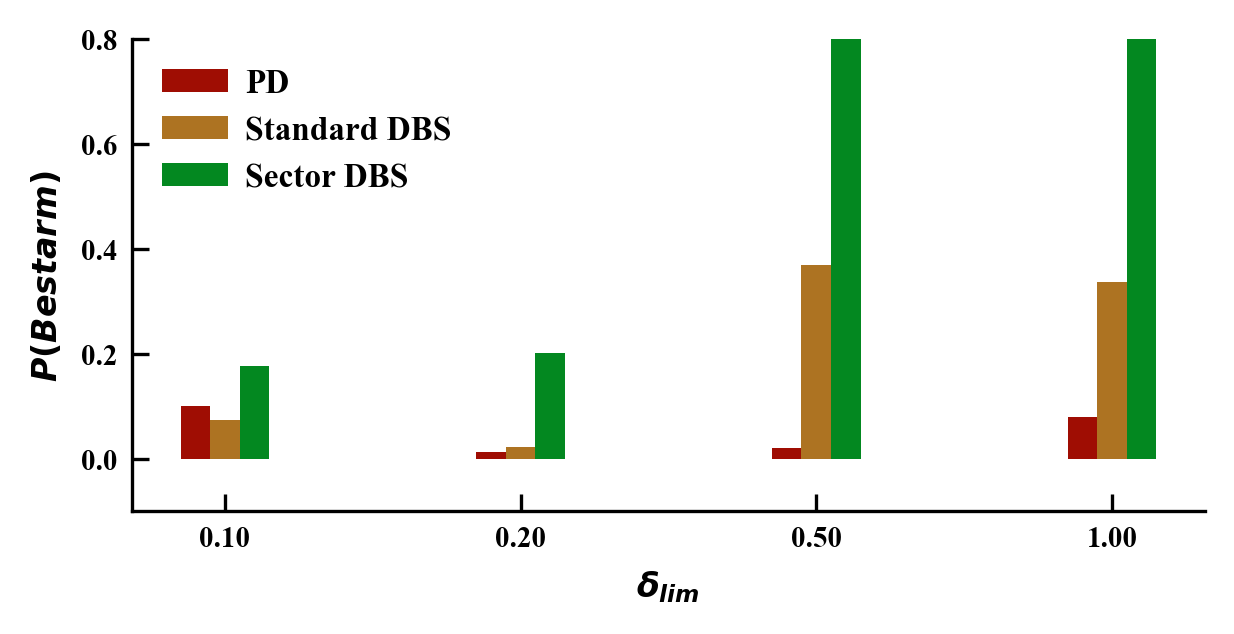

In [ ]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


#+ np.random.randn(len(Last_bin_Probs_std_DBS))*0.01
plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, Last_bin_Probs_PD , width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, Last_bin_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, Last_bin_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 0.8)
plt.show()

In [ ]:
DEL_LIM_ARR_FILTERED = DEL_LIM_ARR
mean_Probs_PD = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[0]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
mean_Probs_std_DBS = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[1]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]
mean_Probs_sector_DBS = [MEAN_PROB_OPTIMAL_MONITOR[TYPE[2]][del_lim] for del_lim in DEL_LIM_ARR_FILTERED]


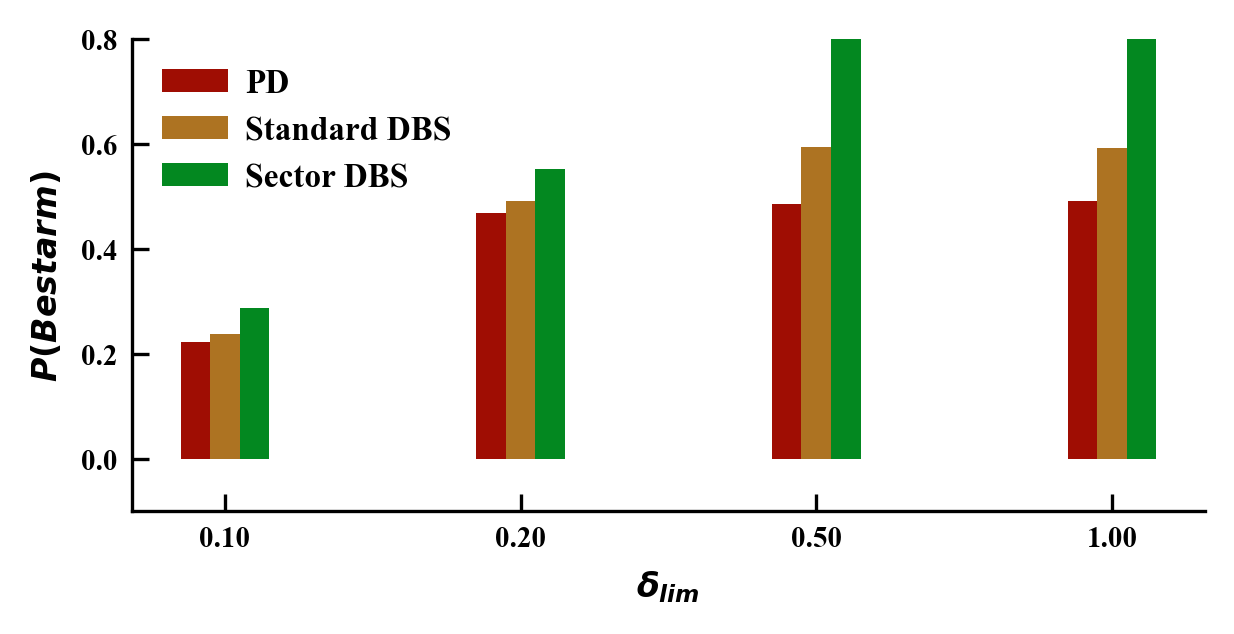

In [ ]:
# plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
bar_width = 0.1
x_values = np.arange(len(DEL_LIM_ARR_FILTERED))
alpha = 1

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}



plt.figure(figsize=(4,2))
plt.bar(x_values - bar_width, mean_Probs_PD + np.random.randn(len(mean_Probs_PD))*0.01, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
plt.bar(x_values, mean_Probs_std_DBS+ np.random.randn(len(mean_Probs_std_DBS))*0.01, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
plt.bar(x_values + bar_width, mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
plt.legend()
plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
plt.xlabel('$\delta_{lim}$')
plt.ylabel('$P(Best arm)$')
plt.ylim(-0.1, 0.8)
plt.show()

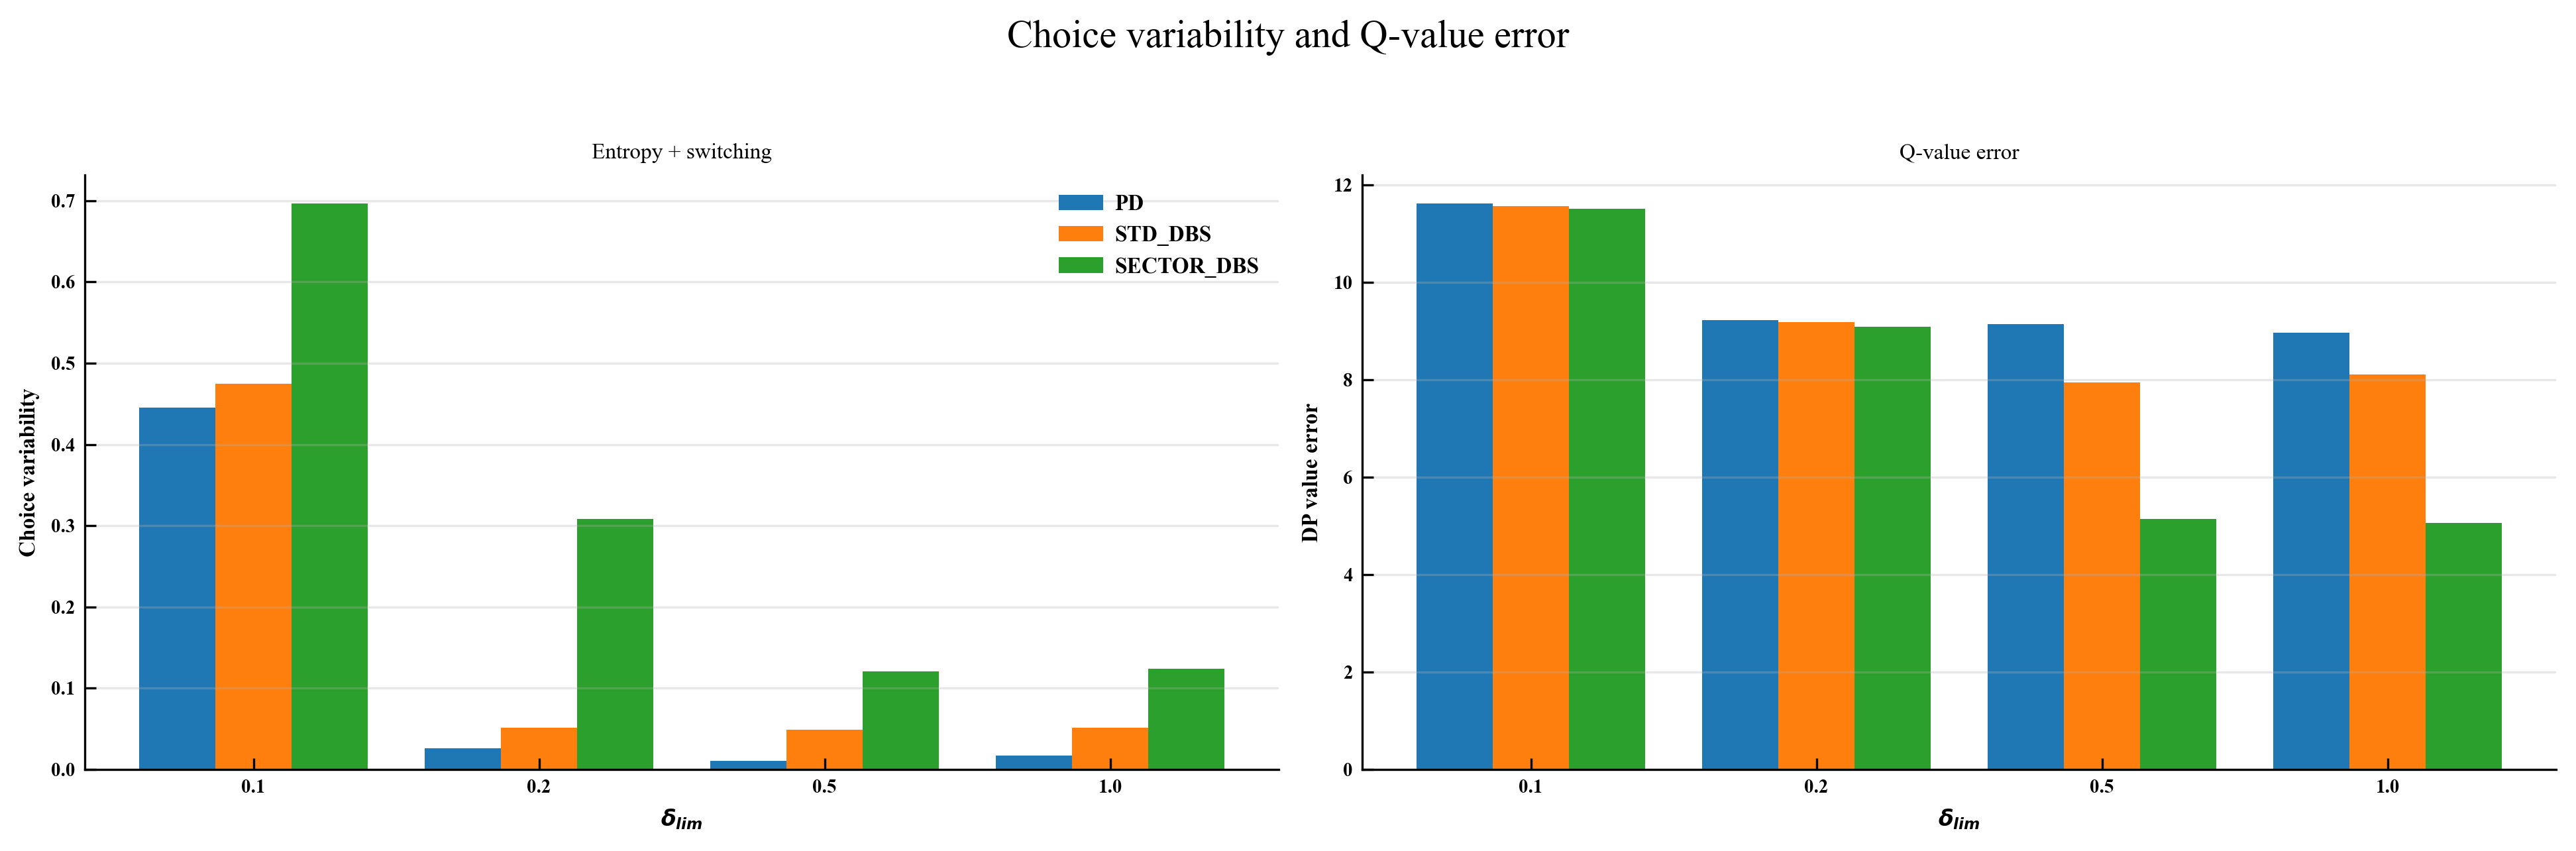

In [ ]:
# # ==================================================
# Bar plots: Entropy + switching and Q-value error
# Uses your existing loop outputs:
# CHOICE_VARIABILITY_METRICS_MONITOR
# Q_ERROR_METRICS_MONITOR
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

conditions = TYPE
delta_vals = DEL_LIM_ARR

x = np.arange(len(delta_vals))
bar_width = 0.8 / len(conditions)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for i, cond in enumerate(conditions):
    offset = (i - (len(conditions) - 1) / 2) * bar_width

    entropy_switching_vals = [
        CHOICE_VARIABILITY_METRICS_MONITOR[cond][del_lim]['mean_combined_variability']
        for del_lim in delta_vals
    ]

    q_error_vals = [
        Q_ERROR_METRICS_MONITOR[cond][del_lim]['mean_q_rmse']
        for del_lim in delta_vals
    ]

    axes[0].bar(
        x + offset,
        entropy_switching_vals,
        width=bar_width,
        label=cond
    )

    axes[1].bar(
        x + offset,
        np.array(q_error_vals) * 100,
        width=bar_width,
        label=cond
    )


axes[0].set_title("Entropy + switching")
axes[0].set_ylabel("Choice variability")
axes[0].set_xlabel(r"$\delta_{lim}$")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(d) for d in delta_vals])
axes[0].grid(axis="y", alpha=0.3)

axes[1].set_title("Q-value error")
axes[1].set_ylabel("DP value error")
axes[1].set_xlabel(r"$\delta_{lim}$")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(d) for d in delta_vals])
axes[1].grid(axis="y", alpha=0.3)

axes[0].legend(frameon=False)

plt.suptitle("Choice variability and Q-value error", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

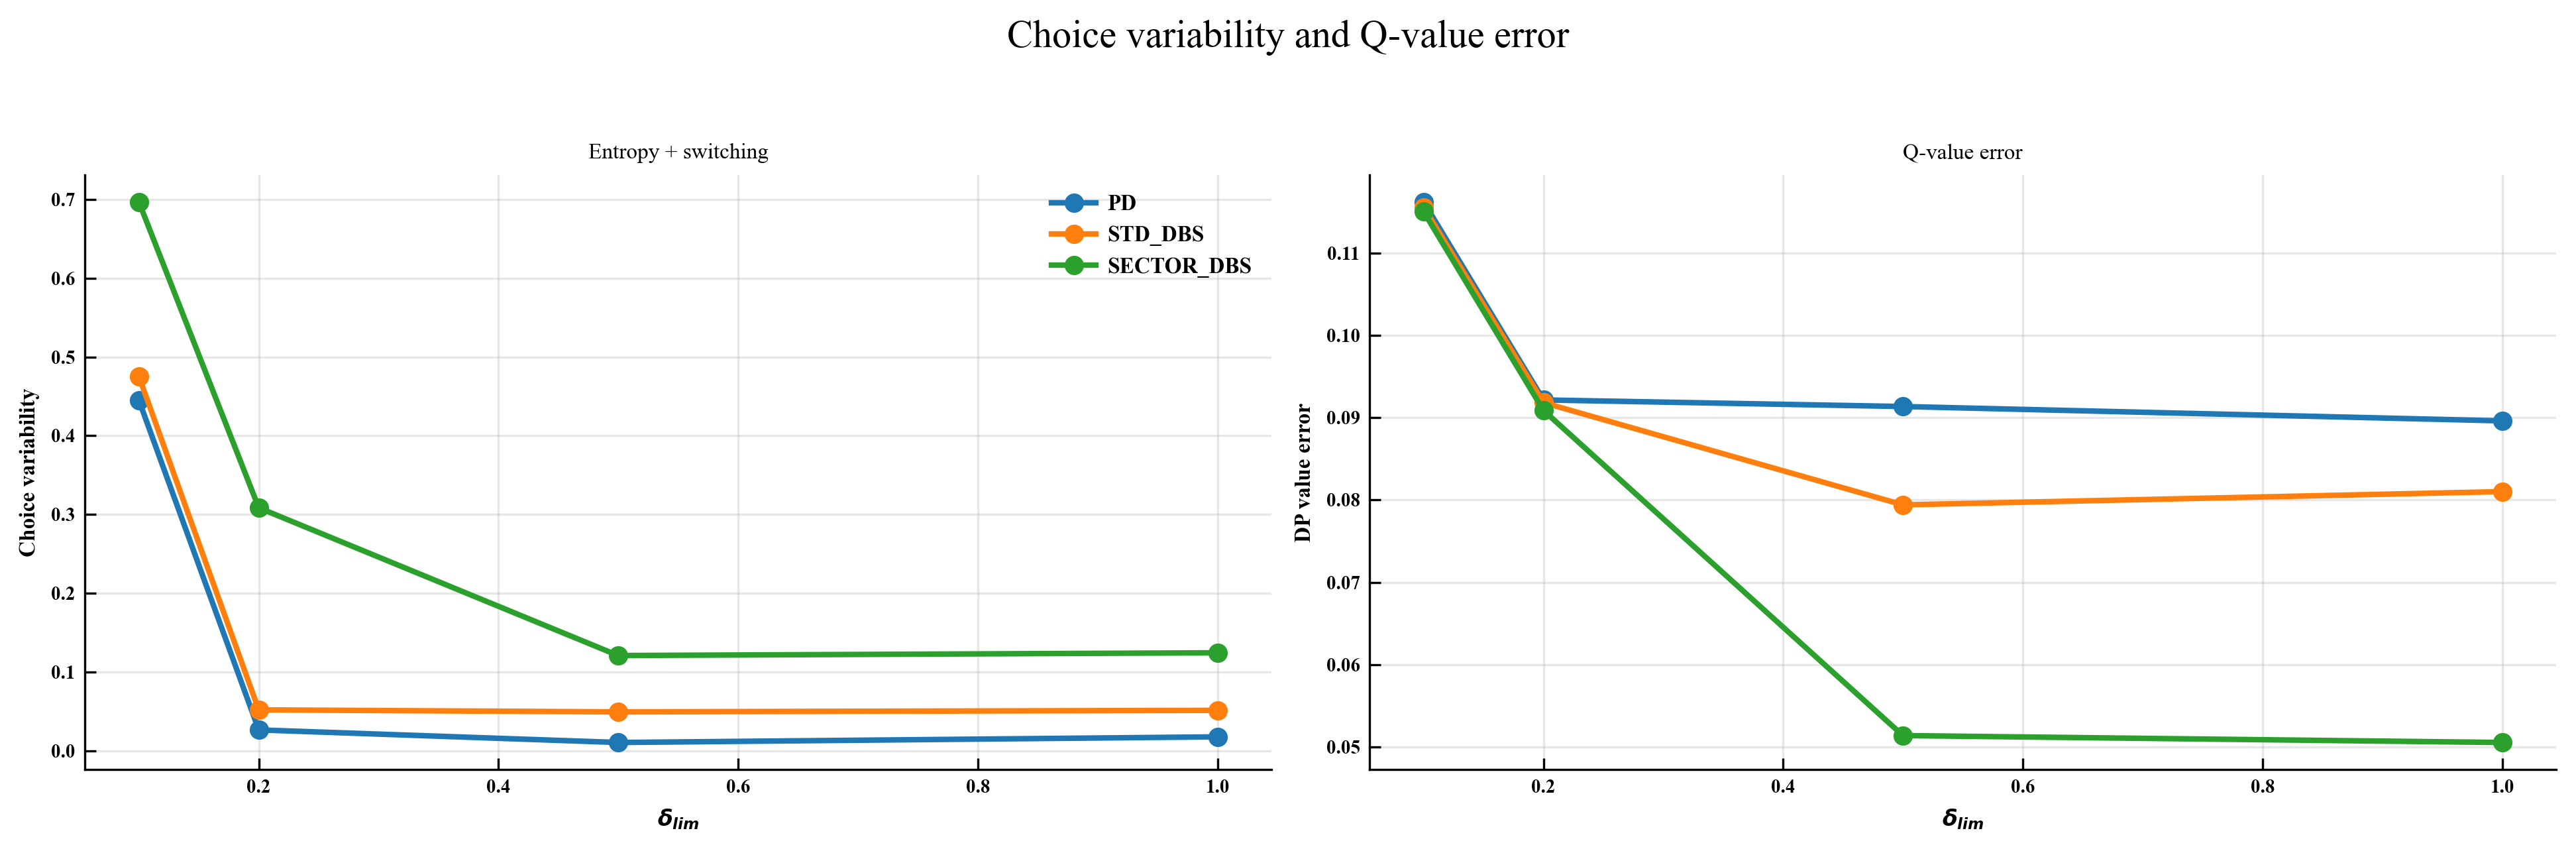

In [ ]:
# ==================================================
# Line plots: Entropy + switching and Q-value error
# Uses your existing loop outputs:
# CHOICE_VARIABILITY_METRICS_MONITOR
# Q_ERROR_METRICS_MONITOR
# ==================================================

import numpy as np
import matplotlib.pyplot as plt

conditions = TYPE
delta_vals = DEL_LIM_ARR

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for cond in conditions:

    entropy_switching_vals = [
        CHOICE_VARIABILITY_METRICS_MONITOR[cond][del_lim]['mean_combined_variability']
        for del_lim in delta_vals
    ]

    q_error_vals = [
        Q_ERROR_METRICS_MONITOR[cond][del_lim]['mean_q_rmse']
        for del_lim in delta_vals
    ]

    axes[0].plot(
        delta_vals,
        entropy_switching_vals,
        marker='o',
        linewidth=2,
        markersize=6,
        label=cond
    )

    axes[1].plot(
        delta_vals,
        q_error_vals,
        marker='o',
        linewidth=2,
        markersize=6,
        label=cond
    )


axes[0].set_title("Entropy + switching")
axes[0].set_ylabel("Choice variability")
axes[0].set_xlabel(r"$\delta_{lim}$")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Q-value error")
axes[1].set_ylabel("DP value error")
axes[1].set_xlabel(r"$\delta_{lim}$")
axes[1].grid(True, alpha=0.3)

axes[0].legend(frameon=False)

plt.suptitle("Choice variability and Q-value error", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# saving separate pickle for choice-variability and Q-error metrics
metrics_data = {
    'DEL_LIM_ARR': DEL_LIM_ARR,
    'TYPE': TYPE,
    'LAT_STRENGTH': LAT_STRENGTH,
    'SCALING_FACTOR': SCALING_FACTOR,
    'NUM_ARMS': NUM_ARMS,
    'TRIALS': TRIALS,
    'EPOCHS': EPOCHS,
    'TIME_STAMP_CHANGE': TIME_STAMP_CHANGE,
    'TRUE_MEAN_REWARDS': TRUE_MEAN_REWARDS,  # normalized reward scale used for DP error
    'TRUE_MEAN_REWARDS_RAW_REFERENCE': TRUE_MEAN_REWARDS * SCALING_FACTOR,
    'BEST_ARM': BEST_ARM,

    # Choice variability = entropy + switching
    'CHOICE_VARIABILITY_METRICS_MONITOR': nested_defaultdict_to_dict(CHOICE_VARIABILITY_METRICS_MONITOR),

    # DP/value controls
    'Q_ERROR_METRICS_MONITOR': nested_defaultdict_to_dict(Q_ERROR_METRICS_MONITOR),

    # Raw monitors included so the metric file is self-contained
    'ARM_MONITOR': nested_defaultdict_to_dict(ARM_MONITOR),
    'DP_MONITOR': nested_defaultdict_to_dict(DP_MONITOR),
    'REWARD_MONITOR': nested_defaultdict_to_dict(REWARD_MONITOR),
}

metrics_file_name = 'non_stationary_bandits_v2_choice_q_metrics_lat_' + str(LAT_STRENGTH).replace('.', '_') + '.pkl'
metrics_file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'non_stationary_bandits', metrics_file_name)

with open(metrics_file_path, 'wb') as f:
    pickle.dump(metrics_data, f)

print("Saved metrics file:", metrics_file_path)



Saved metrics file: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making/simulations/decision_making_tasks/non_stationary_bandits/non_stationary_bandits_v1_choice_q_metrics_lat_0_0425.pkl


In [ ]:
# # saving pickle with lat name
# data = {'DEL_LIM_ARR': DEL_LIM_ARR,
#         'TYPE': TYPE,
#         'ARM_MONITOR': ARM_MONITOR,
#         'LAT_STRENGTH': LAT_STRENGTH,
#         'SCALING_FACTOR': SCALING_FACTOR,
#         'LAST_BIN_PROB_MONITOR': LAST_BIN_PROB_MONITOR,
#         'MEAN_PROB_OPTIMAL_MONITOR': MEAN_PROB_OPTIMAL_MONITOR,
#         'PROB_OPTIMAL_MONITOR': PROB_OPTIMAL_MONITOR,
#         'REWARD_MONITOR': REWARD_MONITOR,
#         'DP_MONITOR': DP_MONITOR}
# file_name = 'non_stationary_bandits_v2_data_lat_' + str(LAT_STRENGTH).replace('.', '_') + '.pkl'
# file_path = os.path.join(project_root, 'simulations', 'decision_making_tasks', 'non_stationary_bandits', file_name)

# with open(file_path, 'wb') as f:
#     pickle.dump(data, f)